# Concentration Jumps

This notebook demonstrates the `scalcs.cjumps` module: computing and visualising macroscopic
open-probability responses to concentration pulses using the Q-matrix formalism
(Colquhoun & Hawkes 1977, 1981).

## Four concentration profiles

| Class | Profile shape | Typical use |
|---|---|---|
| `ErfPulse` | Error-function rise and fall | Fast-perfusion ('rcj') experiments |
| `SquarePulse` | Ideal square step | Analytical relaxation calculations |
| `InstExpPulse` | Instantaneous rise, exponential decay | Outside-out patch synaptic-like waveform |
| `PairedSquarePulse` | Two square pulses with a gap | Paired-pulse (desensitisation) protocols |

All profiles are dataclasses with named, validated parameters and a `.profile(t)` method.  
The solver `cjumps.solve()` accepts any profile and returns a `JumpResult` that supports
4-tuple unpacking for backward compatibility.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from scalcs.samples.samples import CH82
from scalcs import cjumps
from scalcs import qmatlib as qml

# Style defaults
plt.rcParams.update({
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         11,
})

# Colour palette — one per profile
COL = dict(erf='royalblue', square='tomato', instexp='seagreen', paired='darkorange')

## 1 — Reference mechanism: CH82

All calculations use the five-state agonist-gated channel of Colquhoun & Hawkes (1982)
as the numerical example.  This is the same mechanism used throughout the SCALCS test suite.

In [2]:
mec = CH82()
print(mec)


class dcpyps.Mechanism
Values of unit rates [1/sec]:
0	From AR  	to AR*    	beta1   	15.0
1	From A2R  	to A2R*    	beta2   	15000.0
2	From AR*  	to AR    	alpha1   	3000.0
3	From A2R*  	to A2R    	alpha2   	500.0
4	From AR  	to R    	k(-1)   	2000.0
5	From A2R  	to AR    	2k(-2)   	4000.0
6	From R  	to AR    	2k(+1)   	100000000.0
7	From AR*  	to A2R*    	k*(+2)   	500000000.0
8	From AR  	to A2R    	k(+2)   	500000000.0
9	From A2R*  	to AR*    	2k*(-2)   	0.66667

Conductance of state AR* (pS)  =      60

Conductance of state A2R* (pS)  =      60

Number of open states = 2
Number of short-lived shut states (within burst) = 2
Number of long-lived shut states (between bursts) = 1
Number of desensitised states = 0

Number of cycles = 1
Cycle 0 is formed of states: A2R*  AR*  AR  A2R  
	forward product = 1.500007500e+16
	backward product = 1.500000000e+16


## 2 — Solver settings

All four examples below use the same recording length and sampling interval.

In [3]:
RECLEN = 50e-3   # 50 ms recording
STEP   = 5e-6    # 5 µs sampling interval

# Peak concentration used for all profiles
CMAX = 10e-6     # 10 µM

---
## 3 — ErfPulse: realistic fast-perfusion jump

The realistic concentration jump (historically called 'rcj') uses error functions for
rise and fall, mimicking the finite exchange speed of a theta-tube perfusion system.

Parameters:
- `cmax`   — peak concentration
- `width`  — pulse half-width
- `centre` — time of pulse centre
- `rise`   — 10–90 % rise time constant
- `decay`  — 90–10 % decay time constant
- `cb`     — background concentration (default 0)

In [4]:
erf_pulse = cjumps.ErfPulse(
    cmax   = CMAX,
    width  = 10e-3,    # 10 ms pulse
    centre = 10e-3,    # pulse centred at 10 ms
    rise   = 250e-6,   # 250 µs 10-90% rise time
    decay  = 250e-6,   # 250 µs 90-10% decay time
    cb     = 0.0,
)
print(erf_pulse)

ErfPulse(cmax=1e-05, width=0.01, cb=0.0, centre=0.01, rise=0.00025, decay=0.00025)


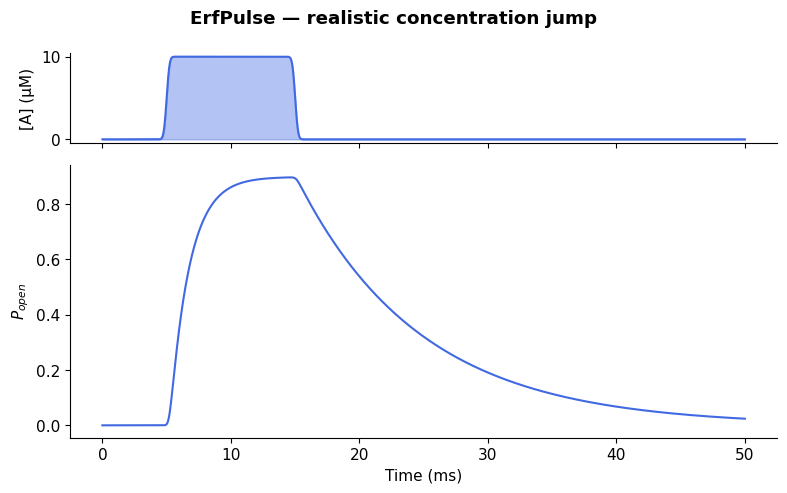

Peak Popen = 0.8965  at t = 14.65 ms


In [5]:
result_erf = cjumps.solve(mec, erf_pulse, RECLEN, STEP)
t, c, Popen, P = result_erf    # 4-tuple unpacking

fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True,
                          gridspec_kw={'height_ratios': [1, 3]})
fig.suptitle('ErfPulse — realistic concentration jump', fontweight='bold')

axes[0].fill_between(t * 1000, c * 1e6, alpha=0.4, color=COL['erf'])
axes[0].plot(t * 1000, c * 1e6, color=COL['erf'])
axes[0].set_ylabel('[A] (µM)')

axes[1].plot(t * 1000, Popen, color=COL['erf'], lw=1.5)
axes[1].set_ylabel('$P_{open}$')
axes[1].set_xlabel('Time (ms)')

fig.tight_layout()
plt.show()

print(f'Peak Popen = {Popen.max():.4f}  at t = {t[Popen.argmax()]*1000:.2f} ms')

### Effect of rise time

Slower solution exchange (longer rise time) reduces the apparent peak Popen.

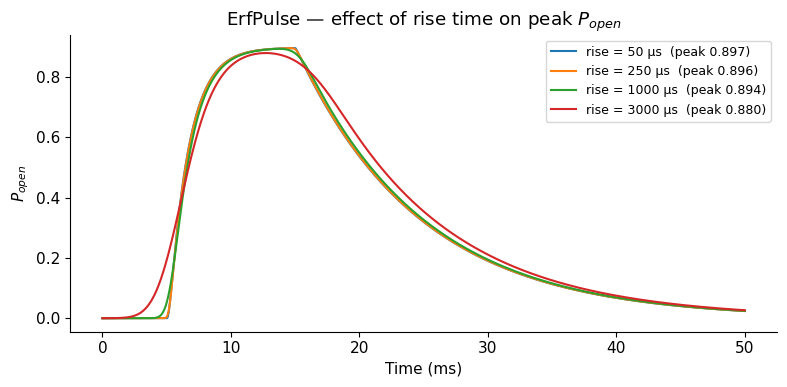

In [6]:
rise_times = [50e-6, 250e-6, 1e-3, 3e-3]   # 50 µs → 3 ms

fig, ax = plt.subplots(figsize=(8, 4))
for rt in rise_times:
    pulse = cjumps.ErfPulse(cmax=CMAX, width=10e-3, centre=10e-3,
                             rise=rt, decay=rt)
    res = cjumps.solve(mec, pulse, RECLEN, STEP)
    ax.plot(res.t * 1000, res.Popen,
            label=f'rise = {rt*1e6:.0f} µs  (peak {res.Popen.max():.3f})')

ax.set_xlabel('Time (ms)')
ax.set_ylabel('$P_{open}$')
ax.set_title('ErfPulse — effect of rise time on peak $P_{open}$')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

---
## 4 — SquarePulse: ideal concentration step

An ideal square pulse is an instantaneous step to `cmax` held for `width` seconds,
then an instantaneous return to `cb`.  This is the profile used for analytical
on/off relaxation calculations.

Parameters:
- `cmax`     — pulse concentration
- `width`    — pulse duration
- `prepulse` — time before the step (default 5 ms)
- `cb`       — background concentration (default 0)

In [7]:
square_pulse = cjumps.SquarePulse(
    cmax     = CMAX,
    width    = 10e-3,
    prepulse = 5e-3,
    cb       = 0.0,
)
print(square_pulse)

SquarePulse(cmax=1e-05, width=0.01, cb=0.0, prepulse=0.005)


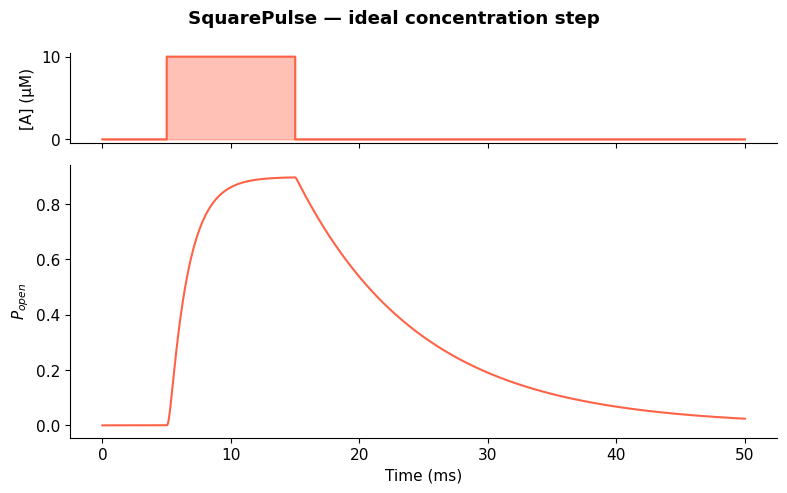

Peak Popen = 0.8969


In [8]:
result_sq = cjumps.solve(mec, square_pulse, RECLEN, STEP)

fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True,
                          gridspec_kw={'height_ratios': [1, 3]})
fig.suptitle('SquarePulse — ideal concentration step', fontweight='bold')

axes[0].fill_between(result_sq.t * 1000, result_sq.c * 1e6,
                     alpha=0.4, color=COL['square'], step='post')
axes[0].plot(result_sq.t * 1000, result_sq.c * 1e6,
             color=COL['square'], drawstyle='steps-post')
axes[0].set_ylabel('[A] (µM)')

axes[1].plot(result_sq.t * 1000, result_sq.Popen, color=COL['square'], lw=1.5)
axes[1].set_ylabel('$P_{open}$')
axes[1].set_xlabel('Time (ms)')

fig.tight_layout()
plt.show()

print(f'Peak Popen = {result_sq.Popen.max():.4f}')

### Analytical on/off relaxation — `relaxation_taus()`

`relaxation_taus()` computes the eigenvalue decomposition of the on- and off-relaxations
analytically (no ODE integration required).  It returns a `RelaxationResult` with
individual and amplitude-weighted time constants for both phases.

In [9]:
rel = cjumps.relaxation_taus(mec, square_pulse)

print('ON-relaxation')
print(f'  Weighted tau_on  = {rel.tau_on_weighted * 1000:.3f} ms')
print('  Individual components:')
for i, (tau, a) in enumerate(zip(rel.tau_on, rel.ampl_on)):
    print(f'    {i+1:d}:  tau = {tau*1000:8.4f} ms   rel. ampl. = {a:+.4f}')

print()
print('OFF-relaxation')
print(f'  Weighted tau_off = {rel.tau_off_weighted * 1000:.3f} ms')
print('  Individual components:')
for i, (tau, a) in enumerate(zip(rel.tau_off, rel.ampl_off)):
    print(f'    {i+1:d}:  tau = {tau*1000:8.4f} ms   rel. ampl. = {a:+.4f}')

ON-relaxation
  Weighted tau_on  = 1.472 ms
  Individual components:
    1:  tau =   0.0480 ms   rel. ampl. = -0.0116
    2:  tau =   0.1247 ms   rel. ampl. = +0.0011
    3:  tau =   0.1666 ms   rel. ampl. = +0.1499
    4:  tau =   1.4966 ms   rel. ampl. = -1.0000

OFF-relaxation
  Weighted tau_off = 9.637 ms
  Individual components:
    1:  tau =   0.0516 ms   rel. ampl. = -0.0054
    2:  tau =   0.3285 ms   rel. ampl. = +0.0000
    3:  tau =   0.5073 ms   rel. ampl. = -0.0004
    4:  tau =   9.6374 ms   rel. ampl. = +1.0000


### Analytical jump summary — `jump_summary()` and `printout()`

`jump_summary()` returns all analytical quantities as a dict (occupancies, eigenvalues,
current amplitudes, areas, weighted taus).  The single-channel conductance `gamma` and
transmembrane voltage `Vm` are explicit parameters — no hard-coded values.

In [10]:
summary = cjumps.jump_summary(mec, square_pulse, gamma=30e-12, Vm=-80e-3)

print('Equilibrium occupancies before pulse (p0):')
for i, p in enumerate(summary['p0']):
    print(f'  state {i+1}: {p:.5g}')

print(f"\nWeighted on tau  = {summary['tau_on_weighted']*1000:.3f} ms")
print(f"Weighted off tau = {summary['tau_off_weighted']*1000:.3f} ms")
print(f"Total on-current at t=0  = {np.sum(summary['amplitudes_on'])*1e12:.3f} pA")
print(f"Total off-current at t=0 = {np.sum(summary['amplitudes_off'])*1e12:.3f} pA")

Equilibrium occupancies before pulse (p0):
  state 1: -0
  state 2: -0
  state 3: -0
  state 4: -0
  state 5: 1

Weighted on tau  = 1.472 ms
Weighted off tau = 9.637 ms
Total on-current at t=0  = 2.156 pA
Total off-current at t=0 = -2.153 pA


In [11]:
# Full formatted report
print(cjumps.printout(mec, square_pulse, gamma=30e-12, Vm=-80e-3))


*******************************************
CONCENTRATION JUMPS

Equilibrium occupancies before t=0, at concentration = 0 mM:
  p0(1) = -0
  p0(2) = -0
  p0(3) = -0
  p0(4) = -0
  p0(5) = 1

Equilibrium occupancies at peak concentration = 0.01 mM:
  pinf(1) = 0.00011975
  pinf(2) = 0.8981
  pinf(3) = 0.023949
  pinf(4) = 0.029937
  pinf(5) = 0.047898

Occupancies at end of 10 ms pulse:
  pt(1) = 0.00012
  pt(2) = 0.89679
  pt(3) = 0.024133
  pt(4) = 0.029951
  pt(5) = 0.049008

Single-channel conductance: 30 pS
Transmembrane voltage:      -80 mV

ON-RELAXATION (ideal step 0 → 0.01 mM):
  Comp      Eigenvalue    Tau (ms)  Ampl (t=0, pA)    Rel. ampl.
     1          -20828    0.048012      0.028943     -0.011554
     2         -8017.9     0.12472    -0.0028676     0.0011447
     3         -6001.6     0.16662      -0.37551        0.1499
     4         -668.16      1.4966        2.5052            -1
  Weighted on tau = 1.4721 ms
  Total current at t=0  = 2.1557 pA
  Total area (on)      

### State occupancies during square pulse

The `P` array in `JumpResult` contains all state occupancies (shape: k × n_timepoints).

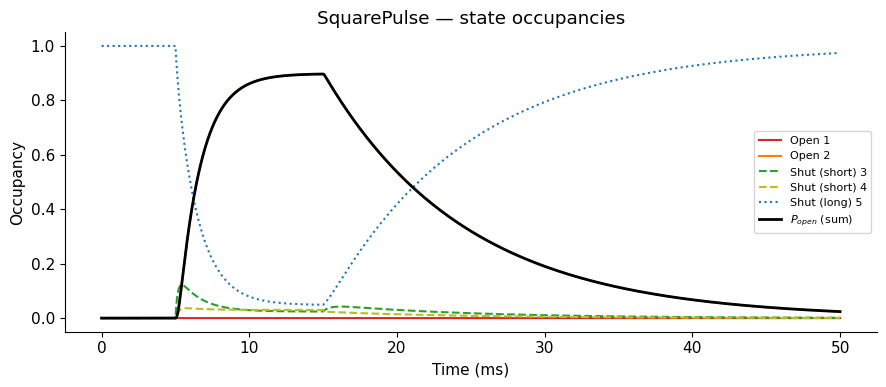

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))

state_colours = ['tab:red', 'tab:orange',           # open states (kA=1)
                 'tab:green', 'tab:olive',           # short-lived shut (kB)
                 'tab:blue', 'tab:cyan', 'tab:purple']  # long-lived shut (kC)

t_sq = result_sq.t * 1000
for i in range(mec.k):
    if i < mec.kA:
        style, label_pfx = '-',  'Open'
    elif i < mec.kA + mec.kB:
        style, label_pfx = '--', 'Shut (short)'
    else:
        style, label_pfx = ':',  'Shut (long)'
    ax.plot(t_sq, result_sq.P[i],
            ls=style, color=state_colours[i % len(state_colours)],
            label=f'{label_pfx} {i+1}')

ax.plot(t_sq, result_sq.Popen, 'k-', lw=2, label='$P_{open}$ (sum)')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Occupancy')
ax.set_title('SquarePulse — state occupancies')
ax.legend(fontsize=8, loc='right')
fig.tight_layout()
plt.show()

---
## 5 — InstExpPulse: instantaneous rise, exponential decay

Mimics a synaptic-like waveform where the agonist concentration reaches its peak
instantaneously (e.g. transmitter release) then decays exponentially as it diffuses
away from the receptor.

Parameters:
- `cmax`     — peak concentration immediately after the step
- `tdec`     — exponential decay time constant
- `prepulse` — baseline period before the step (default 5 ms)
- `cb`       — background concentration (default 0)

In [13]:
instexp_pulse = cjumps.InstExpPulse(
    cmax     = CMAX,
    tdec     = 1e-3,   # 1 ms decay time constant
    prepulse = 5e-3,
    cb       = 0.0,
)
print(instexp_pulse)

InstExpPulse(cmax=1e-05, tdec=0.001, cb=0.0, prepulse=0.005)


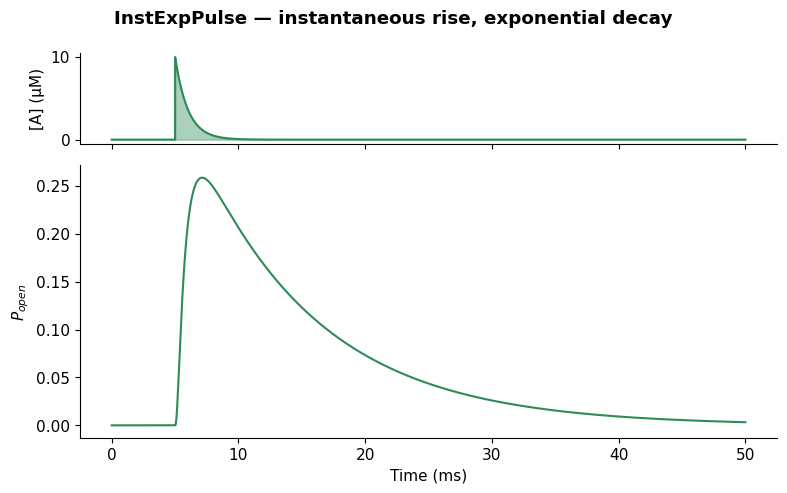

Peak Popen = 0.2585  at t = 7.14 ms


In [14]:
result_ie = cjumps.solve(mec, instexp_pulse, RECLEN, STEP)

fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True,
                          gridspec_kw={'height_ratios': [1, 3]})
fig.suptitle('InstExpPulse — instantaneous rise, exponential decay', fontweight='bold')

axes[0].fill_between(result_ie.t * 1000, result_ie.c * 1e6,
                     alpha=0.4, color=COL['instexp'])
axes[0].plot(result_ie.t * 1000, result_ie.c * 1e6, color=COL['instexp'])
axes[0].set_ylabel('[A] (µM)')

axes[1].plot(result_ie.t * 1000, result_ie.Popen, color=COL['instexp'], lw=1.5)
axes[1].set_ylabel('$P_{open}$')
axes[1].set_xlabel('Time (ms)')

fig.tight_layout()
plt.show()

print(f'Peak Popen = {result_ie.Popen.max():.4f}  at t = {result_ie.t[result_ie.Popen.argmax()]*1000:.2f} ms')

### Effect of decay time constant

A slower decay allows channels more time to activate before the agonist dissipates.

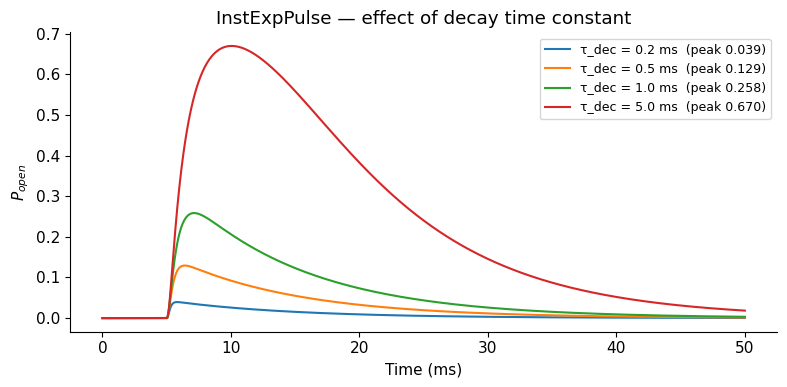

In [15]:
tdec_values = [0.2e-3, 0.5e-3, 1e-3, 5e-3]   # 0.2 ms → 5 ms

fig, ax = plt.subplots(figsize=(8, 4))
for tdec in tdec_values:
    pulse = cjumps.InstExpPulse(cmax=CMAX, tdec=tdec)
    res = cjumps.solve(mec, pulse, RECLEN, STEP)
    ax.plot(res.t * 1000, res.Popen,
            label=f'τ_dec = {tdec*1000:.1f} ms  (peak {res.Popen.max():.3f})')

ax.set_xlabel('Time (ms)')
ax.set_ylabel('$P_{open}$')
ax.set_title('InstExpPulse — effect of decay time constant')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

---
## 6 — PairedSquarePulse: paired-pulse protocol

Two square pulses with a gap between them.  Used in paired-pulse experiments
to study recovery from desensitisation: the response to the second pulse
depends on how much the channel has recovered during the inter-pulse interval.

Parameters:
- `cmax`     — pulse concentration
- `width`    — duration of each pulse
- `inter`    — gap between the two pulses
- `prepulse` — baseline period before the first pulse (default 5 ms)
- `cb`       — background concentration (default 0)

In [16]:
paired_pulse = cjumps.PairedSquarePulse(
    cmax     = CMAX,
    width    = 5e-3,    # 5 ms each pulse
    inter    = 10e-3,   # 10 ms gap
    prepulse = 5e-3,
    cb       = 0.0,
)
print(paired_pulse)

PairedSquarePulse(cmax=1e-05, width=0.005, inter=0.01, cb=0.0, prepulse=0.005)


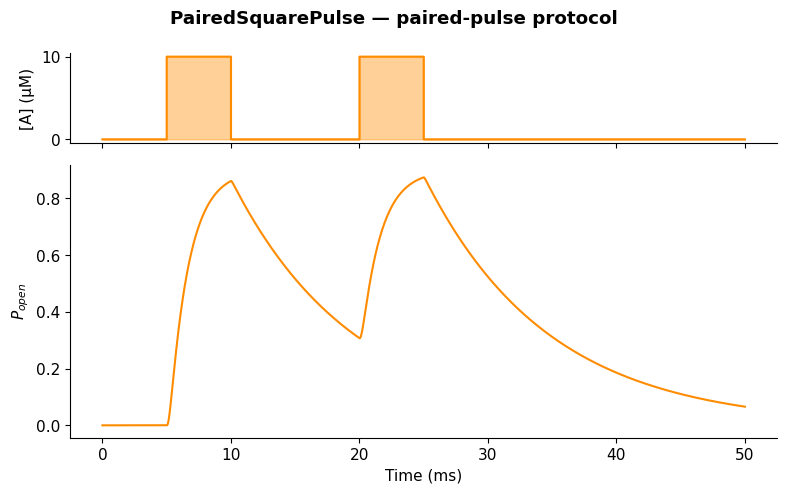

Peak Popen — pulse 1: 0.8614
Peak Popen — pulse 2: 0.8741
Ratio pulse2 / pulse1: 1.015


In [17]:
result_pp = cjumps.solve(mec, paired_pulse, RECLEN, STEP)

fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True,
                          gridspec_kw={'height_ratios': [1, 3]})
fig.suptitle('PairedSquarePulse — paired-pulse protocol', fontweight='bold')

axes[0].fill_between(result_pp.t * 1000, result_pp.c * 1e6,
                     alpha=0.4, color=COL['paired'], step='post')
axes[0].plot(result_pp.t * 1000, result_pp.c * 1e6,
             color=COL['paired'], drawstyle='steps-post')
axes[0].set_ylabel('[A] (µM)')

axes[1].plot(result_pp.t * 1000, result_pp.Popen, color=COL['paired'], lw=1.5)
axes[1].set_ylabel('$P_{open}$')
axes[1].set_xlabel('Time (ms)')

fig.tight_layout()
plt.show()

# Find peak of each pulse
pulse1_mask = (result_pp.t > paired_pulse.prepulse) & \
              (result_pp.t < paired_pulse.prepulse + paired_pulse.width + 10e-3)
pulse2_start = paired_pulse.prepulse + paired_pulse.width + paired_pulse.inter
pulse2_mask = result_pp.t > pulse2_start

peak1 = result_pp.Popen[pulse1_mask].max()
peak2 = result_pp.Popen[pulse2_mask].max()
print(f'Peak Popen — pulse 1: {peak1:.4f}')
print(f'Peak Popen — pulse 2: {peak2:.4f}')
print(f'Ratio pulse2 / pulse1: {peak2/peak1:.3f}')

### Recovery from desensitisation — paired-pulse ratio vs inter-pulse interval

As the gap between pulses increases, the channel recovers and the second response grows.

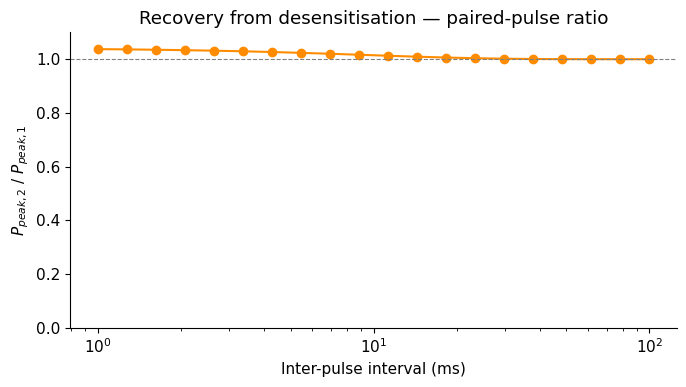

In [18]:
inter_vals = np.logspace(-3, -1, 20)   # 1 ms → 100 ms
ratios = []

for inter in inter_vals:
    # Recording must be long enough to capture both pulses
    total = 5e-3 + 5e-3 + inter + 5e-3 + 20e-3   # prepulse + w1 + inter + w2 + tail
    pulse = cjumps.PairedSquarePulse(cmax=CMAX, width=5e-3, inter=inter)
    res = cjumps.solve(mec, pulse, reclen=total, step=STEP)

    p2_start = pulse.prepulse + pulse.width + inter
    mask1 = (res.t > pulse.prepulse) & (res.t < p2_start)
    mask2 = res.t > p2_start
    pk1 = res.Popen[mask1].max() if mask1.any() else np.nan
    pk2 = res.Popen[mask2].max() if mask2.any() else np.nan
    ratios.append(pk2 / pk1 if pk1 > 0 else np.nan)

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(inter_vals * 1000, ratios, 'o-', color=COL['paired'], lw=1.5)
ax.axhline(1.0, ls='--', color='gray', lw=0.8)
ax.set_xlabel('Inter-pulse interval (ms)')
ax.set_ylabel('$P_{peak,2}$ / $P_{peak,1}$')
ax.set_title('Recovery from desensitisation — paired-pulse ratio')
ax.set_ylim(0, 1.1)
fig.tight_layout()
plt.show()

---
## 7 — All four profiles compared

Same `cmax` and comparable timing; ODE solver in all cases.

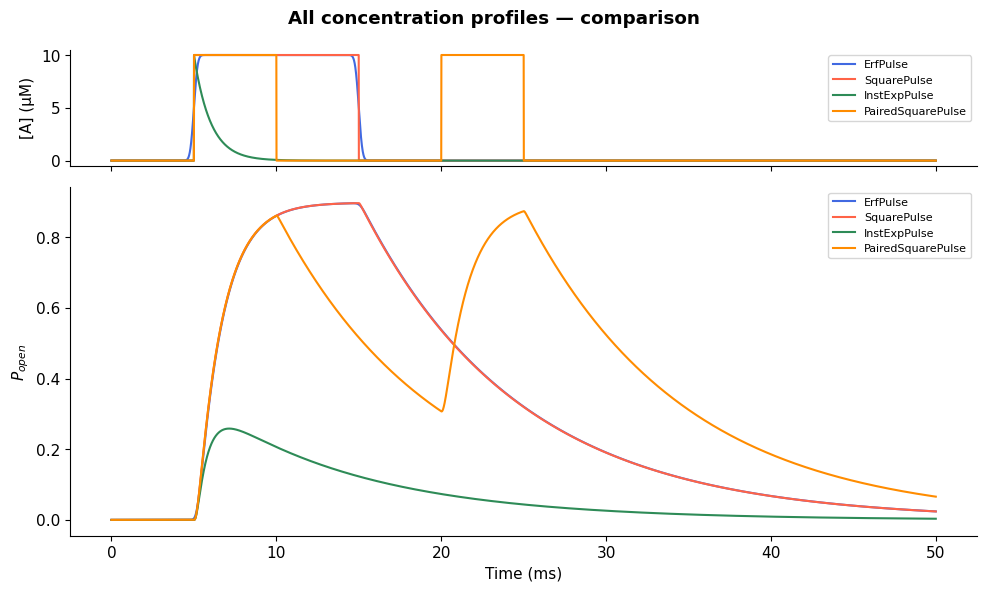

In [19]:
profiles = {
    'ErfPulse':          (cjumps.ErfPulse(cmax=CMAX, width=10e-3, centre=10e-3,
                                           rise=250e-6, decay=250e-6), COL['erf']),
    'SquarePulse':       (cjumps.SquarePulse(cmax=CMAX, width=10e-3, prepulse=5e-3),
                          COL['square']),
    'InstExpPulse':      (cjumps.InstExpPulse(cmax=CMAX, tdec=1e-3, prepulse=5e-3),
                          COL['instexp']),
    'PairedSquarePulse': (cjumps.PairedSquarePulse(cmax=CMAX, width=5e-3,
                                                    inter=10e-3, prepulse=5e-3),
                          COL['paired']),
}

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                          gridspec_kw={'height_ratios': [1, 3]})
fig.suptitle('All concentration profiles — comparison', fontweight='bold')

t_ref = np.arange(0, RECLEN, STEP)

for name, (pulse, colour) in profiles.items():
    c_profile = pulse.profile(t_ref)
    axes[0].plot(t_ref * 1000, c_profile * 1e6, color=colour, label=name, lw=1.5)

    res = cjumps.solve(mec, pulse, RECLEN, STEP)
    axes[1].plot(res.t * 1000, res.Popen, color=colour, label=name, lw=1.5)

axes[0].set_ylabel('[A] (µM)')
axes[0].legend(fontsize=8, loc='upper right')
axes[1].set_ylabel('$P_{open}$')
axes[1].set_xlabel('Time (ms)')
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

---
## 8 — ODE vs matrix solver comparison

`solve()` supports two numerical methods:
- `method='ode'` — scipy `odeint`; robust for all pulse shapes including smooth erf profiles.
- `method='matrix'` — step-wise Q-matrix eigendecomposition; each time step treated as
  a constant-concentration interval.  Useful as an independent numerical check.

Both must agree; the difference reveals the numerical error of each approach.

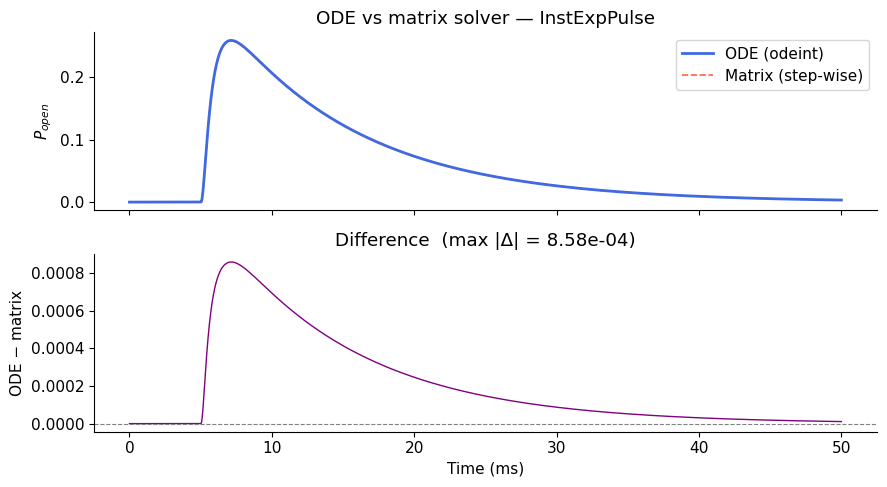

Max |Popen_ode - Popen_matrix| = 8.58e-04
Mean |difference|              = 2.03e-04


In [20]:
res_ode    = cjumps.solve(mec, instexp_pulse, RECLEN, STEP, method='ode')
res_matrix = cjumps.solve(mec, instexp_pulse, RECLEN, STEP, method='matrix')

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)

axes[0].plot(res_ode.t * 1000, res_ode.Popen,
             color='royalblue', lw=2, label='ODE (odeint)', zorder=2)
axes[0].plot(res_matrix.t * 1000, res_matrix.Popen,
             color='tomato', lw=1.2, ls='--', label='Matrix (step-wise)', zorder=1)
axes[0].set_ylabel('$P_{open}$')
axes[0].set_title('ODE vs matrix solver — InstExpPulse')
axes[0].legend()

diff = res_ode.Popen - res_matrix.Popen
axes[1].plot(res_ode.t * 1000, diff, color='purple', lw=1)
axes[1].axhline(0, color='gray', lw=0.8, ls='--')
axes[1].set_ylabel('ODE − matrix')
axes[1].set_xlabel('Time (ms)')
axes[1].set_title(f'Difference  (max |Δ| = {np.abs(diff).max():.2e})')

fig.tight_layout()
plt.show()

print(f'Max |Popen_ode - Popen_matrix| = {np.abs(diff).max():.2e}')
print(f'Mean |difference|              = {np.abs(diff).mean():.2e}')

---
## 9 — Weighted on/off taus vs concentration (SquarePulse)

`relaxation_taus()` is called across a range of concentrations to show how the
on- and off-relaxation time constants vary with agonist concentration.
The on-relaxation speeds up with increasing concentration; the off-relaxation
is determined primarily by the unbinding and channel-closing rates.

This also demonstrates the fix for the `scplotlib` bug: all four arrays
(`tau_on_weighted`, `tau_on`, `tau_off_weighted`, `tau_off`) are now returned
correctly from `relaxation_taus()`.

C:\Users\remis\AppData\Local\Temp\claude\ipykernel_11280\2352680929.py:32: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.semilogx(concs * 1e6, ton[-1] * 1000, '-', color='darkblue', lw=1.2,


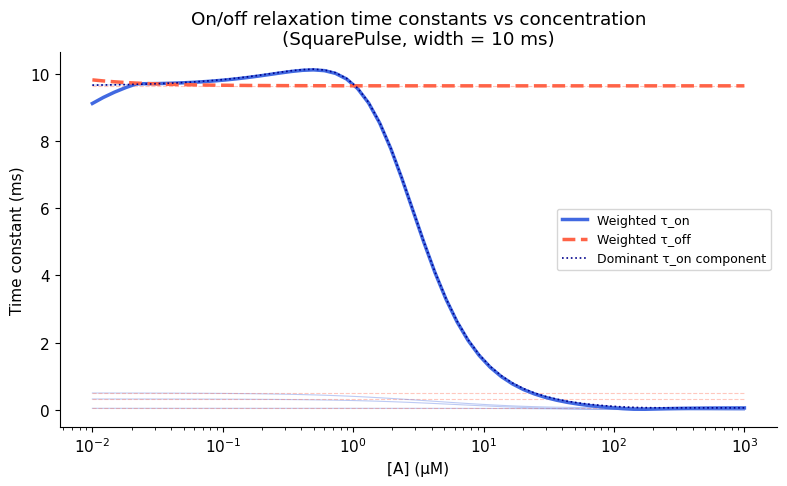

In [21]:
pulse_width = 10e-3
concs = np.logspace(-8, -3, 60)   # 10 nM → 1 mM

wton  = np.zeros(len(concs))
wtoff = np.zeros(len(concs))
ton   = np.zeros((len(concs), mec.k - 1))
toff  = np.zeros((len(concs), mec.k - 1))

for i, c in enumerate(concs):
    pulse = cjumps.SquarePulse(cmax=c, width=pulse_width, cb=0.0)
    rel = cjumps.relaxation_taus(mec, pulse)
    wton[i]  = rel.tau_on_weighted
    wtoff[i] = rel.tau_off_weighted
    ton[i]   = rel.tau_on
    toff[i]  = rel.tau_off

ton  = ton.transpose()    # (k-1) × n_concs
toff = toff.transpose()

fig, ax = plt.subplots(figsize=(8, 5))

# Individual components (thin lines)
for j in range(mec.k - 1):
    ax.semilogx(concs * 1e6, ton[j]  * 1000, '-',  color='royalblue', alpha=0.35, lw=0.8)
    ax.semilogx(concs * 1e6, toff[j] * 1000, '--', color='tomato',    alpha=0.35, lw=0.8)

# Weighted averages (thick lines)
ax.semilogx(concs * 1e6, wton  * 1000, '-',  color='royalblue', lw=2.5, label='Weighted τ_on')
ax.semilogx(concs * 1e6, wtoff * 1000, '--', color='tomato',    lw=2.5, label='Weighted τ_off')

# Dominant (slowest) individual component — dashed red as in GUI
ax.semilogx(concs * 1e6, ton[-1] * 1000, '-', color='darkblue', lw=1.2,
            ls=':', label='Dominant τ_on component')

ax.set_xlabel('[A] (µM)')
ax.set_ylabel('Time constant (ms)')
ax.set_title(f'On/off relaxation time constants vs concentration\n'
             f'(SquarePulse, width = {pulse_width*1000:.0f} ms)')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

---
## 10 — Summary: API reference

```python
# Pulse dataclasses
ErfPulse(cmax, width, cb=0, centre=10e-3, rise=200e-6, decay=200e-6)
SquarePulse(cmax, width, cb=0, prepulse=5e-3)
InstExpPulse(cmax, tdec, cb=0, prepulse=5e-3)
PairedSquarePulse(cmax, width, inter, cb=0, prepulse=5e-3)

# All have .profile(t) → concentration array

# Solver
result = cjumps.solve(mec, pulse, reclen, step, method='ode')   # or 'matrix'
t, c, Popen, P = result   # 4-tuple unpacking (backward compatible)
result.pulse               # pulse object stored in result

# Analytical relaxation — SquarePulse only
rel = cjumps.relaxation_taus(mec, square_pulse)
rel.tau_on_weighted   # float
rel.tau_off_weighted  # float
rel.tau_on            # ndarray, shape (k-1,)
rel.tau_off           # ndarray, shape (k-1,)
rel.ampl_on           # ndarray, shape (k-1,)  normalised amplitudes
rel.ampl_off          # ndarray, shape (k-1,)

# Analytical summary dict — SquarePulse only
summary = cjumps.jump_summary(mec, square_pulse, gamma=30e-12, Vm=-80e-3)

# Formatted text report — SquarePulse only
print(cjumps.printout(mec, square_pulse, gamma=30e-12, Vm=-80e-3))
```